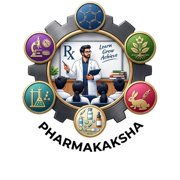

# BP201T · Unit II — Probability and Distributions in Healthcare
**Pharmakaksha · Learn · Grow · Achieve**
*Applied Biostatistics and Data Analytics for Pharmaceutical Sciences · B.Pharm Semester II · PCI NEP 2020*

This notebook contains every example and demo from the Unit II study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP201T_Unit2_Probability_and_Distributions.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP201T_Unit2_Probability_and_Distributions.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import scipy` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. The analyses are for learning statistics only. They are not clinical or regulatory decisions.

## 2.1 Probability basics
**Probability** measures how likely an event is, from 0 (impossible) to 1 (certain): P(event) = favourable outcomes / total outcomes.

A medical ward has **200 patients**: 60 have diabetes (D), 80 have hypertension (H), and 30 have both. This cell loads the libraries and stores the counts.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

In [ ]:
from scipy import stats

total, diab, htn, both = 200, 60, 80, 30
P_D, P_H, P_DH = diab / total, htn / total, both / total
print("P(D) =", P_D, "  P(H) =", P_H, "  P(D and H) =", P_DH)

## 2.2 The addition rule
**P(A or B) = P(A) + P(B) − P(A and B).** We subtract the overlap so patients with both conditions are not counted twice. For **mutually exclusive** events (they cannot happen together) P(A and B) = 0, so P(A or B) = P(A) + P(B).

In [ ]:
P_D_or_H = P_D + P_H - P_DH
print("P(D or H) =", round(P_D_or_H, 2))  # 110 of 200 patients
print("P(neither) =", round(1 - P_D_or_H, 2))

## 2.3 The multiplication rule and conditional probability
**Conditional probability** P(A | B) is the probability of A *given that* B has happened: P(A | B) = P(A and B) / P(B).

**Multiplication rule:** P(A and B) = P(A) × P(B | A). If A and B are **independent**, P(B | A) = P(B), so P(A and B) = P(A) × P(B).

In [ ]:
P_H_given_D = P_DH / P_D
print("P(H | D) =", P_H_given_D)          # half of diabetics are hypertensive
print("P(H)     =", P_H)                  # 0.4 overall
print("Independent?", P_H_given_D == P_H) # no: diabetes raises the chance of hypertension

# Independent events: two unrelated patients each with a 10% ADR risk
print("P(both have an ADR) =", round(0.10 * 0.10, 3))
print("P(neither has an ADR) =", round(0.90 * 0.90, 3))

## 2.4 Bayes' theorem in clinical decisions
A rapid diagnostic test for malaria has **sensitivity 95%** (positive in 95% of people with the disease) and **specificity 90%** (negative in 90% of people without it). If a patient tests positive, how likely is it that they really have malaria?

**Bayes' theorem:** P(Disease | +) = P(+ | Disease) × P(Disease) / P(+), where P(+) = sens × prev + (1 − spec) × (1 − prev). The answer is the **positive predictive value (PPV)**, and it depends on the **prevalence**.

In [ ]:
def ppv(sens, spec, prev):
    true_pos = sens * prev
    false_pos = (1 - spec) * (1 - prev)
    return true_pos / (true_pos + false_pos)

for setting, prev in [("Community screening", 0.02), ("Fever clinic", 0.30)]:
    print(f"{setting:20s} prevalence {prev:.0%}  ->  PPV {ppv(0.95, 0.90, prev):.1%}")

Think of **1,000 people** screened in the community (prevalence 2%):

In [ ]:
n, prev, sens, spec = 1000, 0.02, 0.95, 0.90
sick = n * prev
tp = sens * sick                    # sick and test positive
fp = (1 - spec) * (n - sick)        # healthy but test positive
print(f"True positives {tp:.0f}, false positives {fp:.0f}")
print(f"Of {tp + fp:.0f} positives, only {tp:.0f} are really sick: PPV = {tp / (tp + fp):.1%}")

In [ ]:
prevs = np.linspace(0.005, 0.6, 100)
plt.figure(figsize=(8, 4.5))
plt.plot(prevs * 100, [100 * ppv(0.95, 0.90, p) for p in prevs], color="#17725C", linewidth=2.5)
for p, lab in [(0.02, "Community 2%"), (0.30, "Fever clinic 30%")]:
    plt.scatter(p * 100, 100 * ppv(0.95, 0.90, p), color="#E07A2E", zorder=3, s=60)
    plt.annotate(f"{lab}: PPV {ppv(0.95, 0.90, p):.0%}", (p * 100, 100 * ppv(0.95, 0.90, p)),
                 xytext=(8, -14), textcoords="offset points")
plt.xlabel("Prevalence (%)"); plt.ylabel("PPV: chance a positive is a true case (%)")
plt.title("Same test (sens 95%, spec 90%), different settings")
plt.grid(alpha=0.3); plt.show()

## 2.5 Random variables: discrete and continuous
A **random variable** is a number whose value depends on chance.
- **Discrete:** countable values (0, 1, 2 …): number of responders out of 10 patients, ADR reports per day.
- **Continuous:** any value in a range: tablet weight, blood pressure, AUC.

Discrete variables have a **probability mass function** (bars); continuous variables have a **probability density function** (a smooth curve), where probability is the *area* under the curve.

## 2.6 The binomial distribution: trial outcomes
Use it when there are **n independent trials**, each a success or failure with the same probability **p**. P(X = k) = C(n, k) pᵏ (1 − p)ⁿ⁻ᵏ. Mean = np, SD = √(np(1 − p)).

A drug produces a response in **60%** of patients. We treat **10** patients.

In [ ]:
n, p = 10, 0.6
print("P(exactly 6 respond)  =", round(stats.binom.pmf(6, n, p), 4))
print("P(8 or more respond)  =", round(1 - stats.binom.cdf(7, n, p), 4))
print("P(3 or fewer respond) =", round(stats.binom.cdf(3, n, p), 4))
print("Mean =", n * p, "  SD =", round(np.sqrt(n * p * (1 - p)), 2))

In [ ]:
k = np.arange(0, 11)
plt.figure(figsize=(8, 4.5))
plt.bar(k, stats.binom.pmf(k, n, p), color=["#E07A2E" if x == 6 else "#1F8A70" for x in k], edgecolor="white")
plt.xticks(k); plt.xlabel("Number of responders out of 10"); plt.ylabel("Probability")
plt.title("Binomial(n = 10, p = 0.6): most likely 6 responders")
plt.grid(axis="y", alpha=0.3); plt.show()

## 2.7 The Poisson distribution: rare events such as ADRs
Use it for **counts of rare events** in a fixed time or population, when events happen independently at an average rate **λ** (lambda). P(X = k) = e^(−λ) λᵏ / k!. Mean = variance = λ.

A serious ADR occurs in about **1 in 1,000** patients. A hospital treats **2,000** patients, so λ = 2.

In [ ]:
lam = 2
print("P(no case)      =", round(stats.poisson.pmf(0, lam), 4))
print("P(at least one) =", round(1 - stats.poisson.pmf(0, lam), 4))
print("P(5 or more)    =", round(1 - stats.poisson.cdf(4, lam), 4))

Real data: `adr_daily_counts.csv` holds the number of ADR reports received each day for a year by a hospital pharmacovigilance cell. Do the counts follow a Poisson distribution?

In [ ]:
adr = load("adr_daily_counts.csv")
counts = adr["adr_reports"]
lam = counts.mean()
print("Days:", len(counts), "  mean:", round(lam, 2), "  variance:", round(counts.var(), 2))

observed = counts.value_counts().sort_index()
expected = (stats.poisson.pmf(observed.index, lam) * len(counts)).round(1)
pd.DataFrame({"observed days": observed, "Poisson expected": expected})

In [ ]:
kk = observed.index
plt.figure(figsize=(8, 4.5))
plt.bar(kk - 0.2, observed.values, width=0.4, color="#1F8A70", label="Observed days")
plt.bar(kk + 0.2, stats.poisson.pmf(kk, lam) * len(counts), width=0.4, color="#E07A2E", label=f"Poisson (λ = {lam:.2f})")
plt.xticks(kk); plt.xlabel("ADR reports in a day"); plt.ylabel("Number of days")
plt.title("Daily ADR reports follow a Poisson distribution")
plt.legend(); plt.grid(axis="y", alpha=0.3); plt.show()

## 2.8 The normal distribution
The bell-shaped **normal distribution** is described by its mean μ and SD σ. Many biological and QC measurements are close to normal. The **68–95–99.7 rule**: about 68% of values lie within μ ± 1σ, 95% within μ ± 2σ and 99.7% within μ ± 3σ.

The **z-score** z = (x − μ) / σ tells how many SDs a value is from the mean.

A tablet press makes tablets with mean weight **250 mg** and SD **4 mg**.

In [ ]:
mu, sd = 250, 4
for k in [1, 2, 3]:
    print(f"Within ±{k} SD: {stats.norm.cdf(k) - stats.norm.cdf(-k):.4f}")

z = (262.5 - mu) / sd
print("z for 262.5 mg =", z)
p_out = stats.norm.cdf(237.5, mu, sd) + (1 - stats.norm.cdf(262.5, mu, sd))
print(f"P(outside 237.5-262.5 mg) = {p_out:.5f}  (about {p_out * 10000:.0f} per 10,000 tablets)")

In [ ]:
x = np.linspace(234, 266, 400)
y = stats.norm.pdf(x, mu, sd)
plt.figure(figsize=(8, 4.5))
plt.plot(x, y, color="#12303A", linewidth=2)
for k, c in [(3, "#DFF3EC"), (2, "#9FD9C5"), (1, "#1F8A70")]:
    m = (x >= mu - k * sd) & (x <= mu + k * sd)
    plt.fill_between(x[m], y[m], color=c, label=f"μ ± {k}σ")
plt.axvline(237.5, color="#E07A2E", linestyle="--"); plt.axvline(262.5, color="#E07A2E", linestyle="--", label="IP limits ±5%")
plt.xlabel("Tablet weight (mg)"); plt.ylabel("Density")
plt.title("Normal(250, 4): the 68–95–99.7 rule")
plt.legend(); plt.show()

## 2.9 Plotting distributions in Python: a summary
| Distribution | Type | Parameters | SciPy | Pharma use |
|---|---|---|---|---|
| Binomial | Discrete | n, p | `stats.binom.pmf(k, n, p)` | Responders in a trial |
| Poisson | Discrete | λ | `stats.poisson.pmf(k, lam)` | Rare ADRs, daily reports |
| Normal | Continuous | μ, σ | `stats.norm.pdf(x, mu, sd)` | Weights, BP, lab values |

`pmf` = probability of an exact count; `pdf` = height of a continuous curve; `cdf` = probability of a value **at or below** x. Random samples come from `rvs` (or NumPy's random generator).

In [ ]:
rng = np.random.default_rng(1)
sim = rng.normal(250, 4, 5000)          # 5,000 simulated tablets
plt.figure(figsize=(8, 4.5))
plt.hist(sim, bins=40, density=True, color="#9FD9C5", edgecolor="white", label="5,000 simulated tablets")
plt.plot(x, stats.norm.pdf(x, 250, 4), color="#E07A2E", linewidth=2.5, label="Normal(250, 4) curve")
plt.xlabel("Tablet weight (mg)"); plt.ylabel("Density"); plt.legend()
plt.title("A histogram of simulated data matches the normal curve"); plt.show()

## Quick check
In a hospital, 1 in 2,000 patients has a serious allergic reaction to a contrast dye. In 6,000 patients, what is the chance of **no** reactions? Which distribution? Decide, then run the cell.

In [ ]:
print("Poisson with λ = 6000 / 2000 = 3:  P(0) =", round(stats.poisson.pmf(0, 3), 3))

## Try it yourself (lab)
**1.** In the ward of 200 patients, what is P(D | H), the chance a hypertensive patient is diabetic?

**2.** A test has sensitivity 90% and specificity 95%. Find the PPV at prevalence 1%, 10% and 50%.

**3.** A vaccine causes a fever in 15% of children. In a group of 20 children, find P(no fever), P(exactly 3) and P(5 or more).

**4.** Fasting glucose in healthy adults is roughly Normal(90, 10) mg/dL. What percentage is above 110 mg/dL?

---
## Solutions

In [ ]:
# 1
print("P(D | H) =", 30 / 80)

In [ ]:
# 2
for prev in [0.01, 0.10, 0.50]:
    print(prev, round(ppv(0.90, 0.95, prev), 3))

In [ ]:
# 3
print(round(stats.binom.pmf(0, 20, 0.15), 4), round(stats.binom.pmf(3, 20, 0.15), 4),
      round(1 - stats.binom.cdf(4, 20, 0.15), 4))

In [ ]:
# 4
print(round(100 * (1 - stats.norm.cdf(110, 90, 10)), 2), "%")

---
**Next:** Unit III — Sampling and Statistical Inference. Pharmakaksha · Learn · Grow · Achieve